In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.style.use("ggplot")

In [41]:
import os

BASE_DIR = r"C:\Users\sb231\OneDrive\Desktop\bluestock DA"

processed = os.path.join(BASE_DIR,"data","processed")

In [43]:
fund = pd.read_csv(os.path.join(processed,r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\DAY 1 — Project Setup + Data Ingestion (ETL) DONE TASK\data\processed\fund_master_clean.csv"))

nav = pd.read_csv(os.path.join(processed,r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Data Cleaning + SQL Database Design\bluestock DA\data\processed\nav_history.csv"))

performance = pd.read_csv(os.path.join(processed,r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Data Cleaning + SQL Database Design\bluestock DA\data\processed\scheme_performance.csv"))

benchmark = pd.read_csv(os.path.join(processed,r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\10_benchmark_indices.csv"))

In [44]:
print(fund.shape)

print(nav.shape)

print(performance.shape)

print(benchmark.shape)

(40, 15)
(46000, 3)
(40, 19)
(8050, 3)


In [45]:
nav["date"] = pd.to_datetime(nav["date"])

In [46]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [47]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [48]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

In [49]:
nav.reset_index(
    drop=True,
    inplace=True
)

In [50]:
nav["daily_return"] = (

nav.groupby("amfi_code")["nav"]

.pct_change()

)

In [51]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [52]:
nav["daily_return"].isnull().sum()

np.int64(40)

In [53]:
nav = nav.dropna(
    subset=["daily_return"]
)

In [54]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

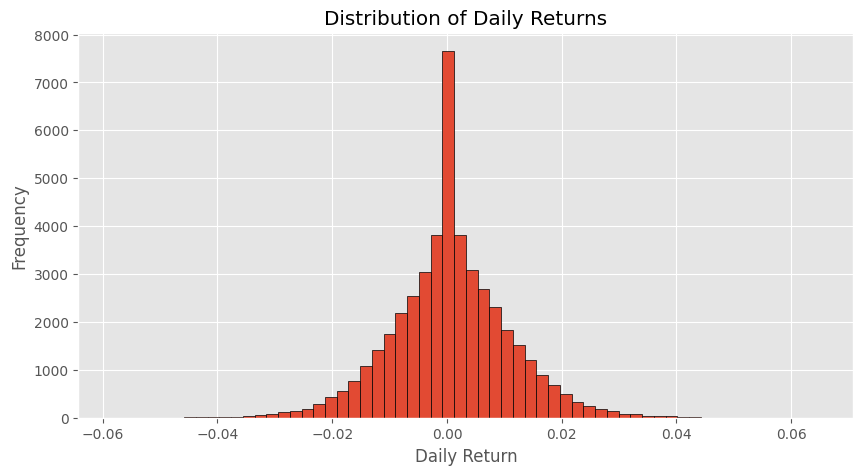

In [55]:
plt.figure(figsize=(10,5))

plt.hist(
    nav["daily_return"],
    bins=60,
    edgecolor="black"
)

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.title("Distribution of Daily Returns")

plt.show()

In [56]:
outliers = nav[

(nav["daily_return"]>0.20)

|

(nav["daily_return"]<-0.20)

]

In [57]:
outliers

,amfi_code,date,nav,daily_return


In [66]:
nav.to_csv(
    r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\DAY 1 — Project Setup + Data Ingestion (ETL) DONE TASK\data\processed\nav_history_clean.csv",
    index=False
)

In [61]:
print(processed)

C:\Users\sb231\OneDrive\Desktop\bluestock DA\data\processed


In [62]:
import os

print(os.path.exists(processed))

False


In [64]:
print(processed)

import os
print(os.path.exists(processed))

C:\Users\sb231\OneDrive\Desktop\bluestock DA\data\processed
False


In [67]:
nav.to_csv(

os.path.join(

processed,

r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\DAY 1 — Project Setup + Data Ingestion (ETL) DONE TASK\data\processed\nav_history_clean.csv",

),

index=False

)

In [83]:
performance = pd.read_csv(
    os.path.join(processed, r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\raw\07_scheme_performance.csv")
)

In [70]:
print(performance.columns.tolist())


['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [71]:
cagr_table = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
]

In [72]:
cagr_table.head()

,amfi_code,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,119552,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [73]:
cagr_table = cagr_table.rename(
    columns={
        "return_1yr_pct":"CAGR_1Y",
        "return_3yr_pct":"CAGR_3Y",
        "return_5yr_pct":"CAGR_5Y"
    }
)

In [74]:
cagr_table["Rank_3Y"] = (
    cagr_table["CAGR_3Y"]
    .rank(
        ascending=False
    )
)

In [75]:
cagr_table = cagr_table.sort_values(
    "Rank_3Y"
)

In [76]:
cagr_table.head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Rank_3Y
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67,1.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82,2.0
29,101207,ABSL Small Cap Fund - Regular - Growth,24.93,22.38,23.80,3.0
27,119095,Axis Small Cap Fund - Regular - Growth,21.97,20.98,22.62,4.0
17,118634,Nippon India Small Cap Fund - Regular - Growth,21.30,20.15,21.88,5.0
39,149324,DSP Small Cap Fund - Regular - Growth,20.20,20.08,20.61,6.0
21,120842,Kotak Emerging Equity Fund - Regular - Growth,17.12,18.23,17.75,7.0
12,120505,ICICI Pru Midcap Fund - Regular - Growth,14.02,18.08,17.55,8.0
38,149323,DSP Midcap Fund - Regular - Growth,14.12,17.16,19.00,9.0
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,15.43,16.58,17.69,10.0


In [77]:
cagr_table[
[
"CAGR_1Y",
"CAGR_3Y",
"CAGR_5Y"
]
].describe()

,CAGR_1Y,CAGR_3Y,CAGR_5Y
count,40.000000,40.000000,40.000000
mean,14.376000,14.089000,14.516750
std,4.883023,4.617253,4.454021
min,4.260000,5.140000,5.430000
25%,11.735000,12.035000,12.340000
50%,14.620000,14.205000,14.185000
75%,16.392500,15.882500,17.585000
max,24.930000,23.390000,23.800000


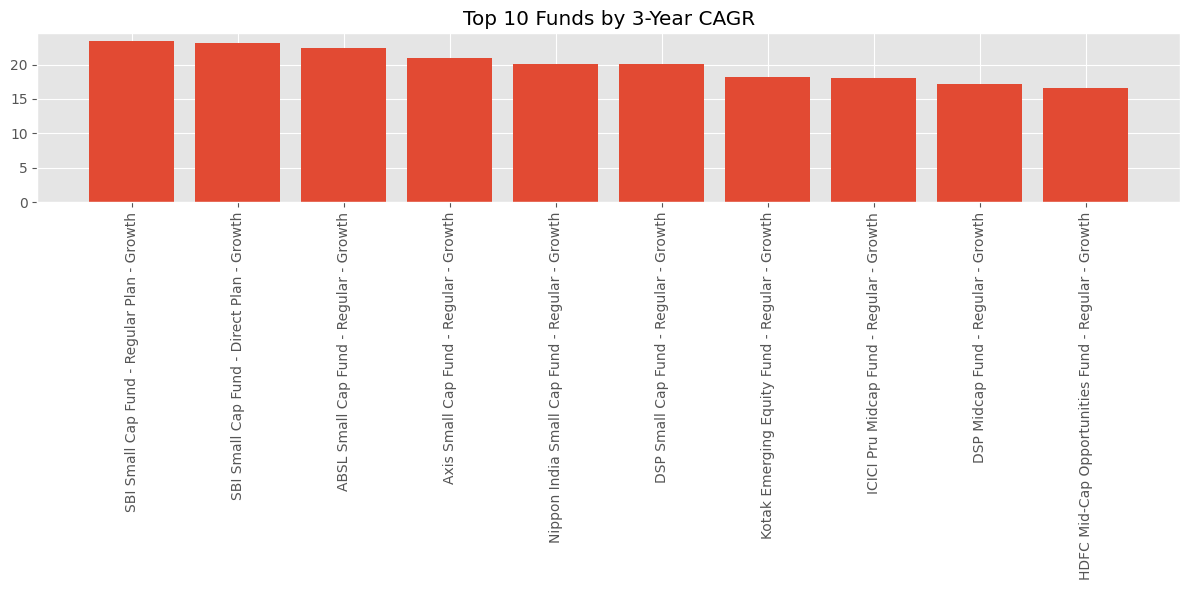

In [78]:
plt.figure(figsize=(12,6))

top10 = cagr_table.head(10)

plt.bar(
    top10["scheme_name"],
    top10["CAGR_3Y"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by 3-Year CAGR")

plt.tight_layout()

plt.show()

In [81]:
cagr_table.to_csv(
    os.path.join(
        processed,
        r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\processed\cagr_comparison.csv"
    ),
    index=False
)

In [84]:
print(performance.columns.tolist())


['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [86]:
performance["sharpe_ratio"].isnull().sum()

np.int64(0)

In [87]:
performance["sharpe_ratio"].describe()

count    40.000000
mean      1.361750
std       1.475805
min       0.800000
25%       0.865000
50%       0.925000
75%       0.985000
max       7.680000
Name: sharpe_ratio, dtype: float64

In [88]:
performance["Sharpe_Rank"] = (
    performance["sharpe_ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [89]:
sharpe_table = performance.sort_values(
    "Sharpe_Rank"
)

In [90]:
sharpe_table.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Sharpe_Rank
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low,1.0
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low,2.0
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low,3.0
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low,4.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,5.0
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,0.37,1.33,2.38,4.0,-2.23,30030,0.55,4,Low,6.0
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate,7.0
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate,7.0
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate,8.0
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,0.88,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate,9.0


In [91]:
top10 = sharpe_table.head(10)

top10[
[
"scheme_name",
"sharpe_ratio",
"Sharpe_Rank"
]
]

,scheme_name,sharpe_ratio,Sharpe_Rank
14,ICICI Pru Liquid Fund - Regular - Growth,7.68,1.0
23,Kotak Liquid Fund - Regular - Growth,6.18,2.0
30,ABSL Liquid Fund - Regular - Growth,5.14,3.0
9,HDFC Short Term Debt Fund - Regular - Growth,1.84,4.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52,5.0
19,Nippon India Gilt Securities Fund - Regular - ...,1.33,6.0
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06,7.0
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06,7.0
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03,8.0
15,Nippon India Large Cap Fund - Regular - Growth,1.00,9.0


In [92]:
top10 = sharpe_table.head(10)

top10[
[
"scheme_name",
"sharpe_ratio",
"Sharpe_Rank"
]
]

,scheme_name,sharpe_ratio,Sharpe_Rank
14,ICICI Pru Liquid Fund - Regular - Growth,7.68,1.0
23,Kotak Liquid Fund - Regular - Growth,6.18,2.0
30,ABSL Liquid Fund - Regular - Growth,5.14,3.0
9,HDFC Short Term Debt Fund - Regular - Growth,1.84,4.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52,5.0
19,Nippon India Gilt Securities Fund - Regular - ...,1.33,6.0
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06,7.0
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06,7.0
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03,8.0
15,Nippon India Large Cap Fund - Regular - Growth,1.00,9.0


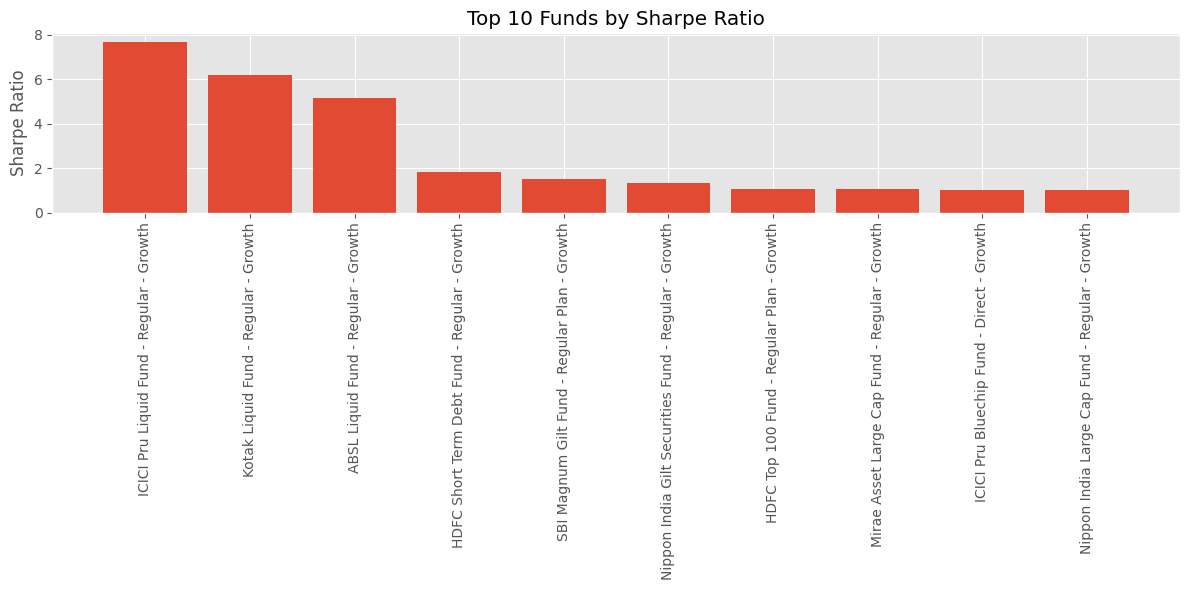

In [93]:
plt.figure(figsize=(12,6))

plt.bar(
    top10["scheme_name"],
    top10["sharpe_ratio"]
)

plt.xticks(rotation=90)

plt.ylabel("Sharpe Ratio")

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.show()

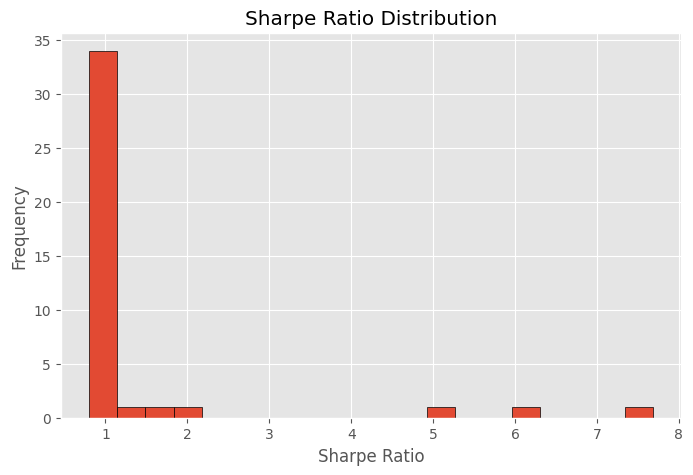

In [94]:
plt.figure(figsize=(8,5))

plt.hist(
    performance["sharpe_ratio"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Sharpe Ratio")

plt.ylabel("Frequency")

plt.title("Sharpe Ratio Distribution")

plt.show()

In [97]:
sharpe_table.to_csv(
    os.path.join(
        processed,
        r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\processed\sharp_ranking.csv"
    ),
    index=False
)

In [98]:
performance["sortino_ratio"].isnull().sum()

np.int64(0)

In [99]:
performance["sortino_ratio"].describe()

count    40.000000
mean      2.082500
std       2.203144
min       1.030000
25%       1.270000
50%       1.445000
75%       1.637500
max      10.370000
Name: sortino_ratio, dtype: float64

In [100]:
performance["Sortino_Rank"] = (
    performance["sortino_ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [101]:
sortino_table = performance.sort_values(
    "Sortino_Rank"
)

In [102]:
sortino_table.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Sharpe_Rank,Sortino_Rank
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,7.68,10.37,0.5,-2.62,39116,0.74,5,Low,1.0,1.0
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,...,6.18,9.70,0.5,-3.81,27623,0.60,3,Low,2.0,2.0
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,...,5.14,8.76,0.5,-3.66,38995,0.79,5,Low,3.0,3.0
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,1.84,2.79,4.0,-6.01,27953,0.56,3,Low,4.0,4.0
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,...,1.33,2.38,4.0,-2.23,30030,0.55,4,Low,6.0,5.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,5.0,6.0
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate,7.0,7.0
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,...,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate,9.0,8.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,14.0,9.0
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate,7.0,10.0


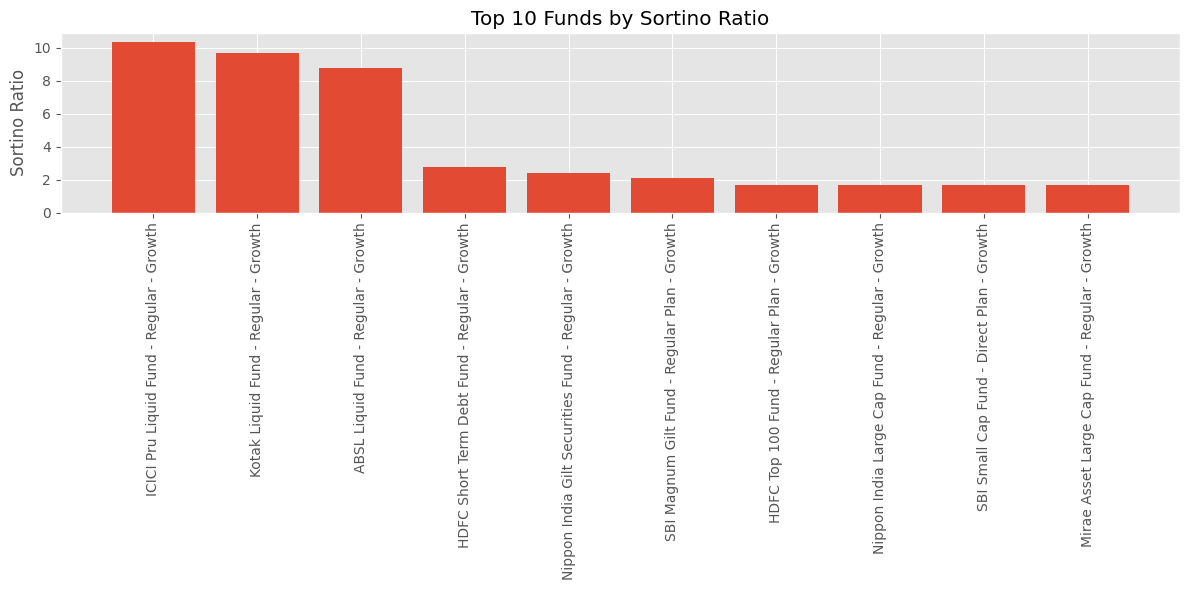

In [103]:
plt.figure(figsize=(12,6))

top10 = sortino_table.head(10)

plt.bar(
    top10["scheme_name"],
    top10["sortino_ratio"]
)

plt.xticks(rotation=90)

plt.ylabel("Sortino Ratio")

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.show()

In [105]:
sortino_table.to_csv(
    os.path.join(
        processed,
        r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\processed\sortino_ranking.csv"
    ),
    index=False
)

In [106]:
print("Missing Alpha :", performance["alpha"].isnull().sum())

print("Missing Beta :", performance["beta"].isnull().sum())

Missing Alpha : 0
Missing Beta : 0


In [107]:
performance[["alpha","beta"]].describe()

,alpha,beta
count,40.000000,40.000000
mean,1.253500,0.873250
std,0.447412,0.224846
min,0.510000,0.220000
25%,0.887500,0.890000
50%,1.205000,0.960000
75%,1.700000,1.000000
max,1.980000,1.040000


In [108]:
performance["Alpha_Rank"] = (
    performance["alpha"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [109]:
performance["Beta_Rank"] = (
    performance["beta"]
    .rank(
        ascending=True,
        method="dense"
    )
)

In [110]:
alpha_beta = performance[
[
"amfi_code",
"scheme_name",
"alpha",
"beta",
"Alpha_Rank",
"Beta_Rank"
]
]

In [111]:
alpha_beta.head()

,amfi_code,scheme_name,alpha,beta,Alpha_Rank,Beta_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89,28.0,9.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87,8.0,7.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89,18.0,9.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04,20.0,22.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22,11.0,1.0


In [112]:
top_alpha = alpha_beta.sort_values(
    "Alpha_Rank"
)

top_alpha.head(10)

,amfi_code,scheme_name,alpha,beta,Alpha_Rank,Beta_Rank
9,100025,HDFC Short Term Debt Fund - Regular - Growth,1.98,0.44,1.0,5.0
21,120842,Kotak Emerging Equity Fund - Regular - Growth,1.91,1.00,2.0,19.0
22,120843,Kotak Flexicap Fund - Regular - Growth,1.85,0.95,3.0,14.0
14,120507,ICICI Pru Liquid Fund - Regular - Growth,1.85,0.26,3.0,2.0
29,101207,ABSL Small Cap Fund - Regular - Growth,1.84,0.97,4.0,16.0
37,149322,DSP Top 100 Equity Fund - Regular - Growth,1.82,0.91,5.0,11.0
18,118635,Nippon India ETF Nifty 50 BeES,1.80,1.04,6.0,22.0
33,102887,UTI Flexi Cap Fund - Regular - Growth,1.79,1.00,7.0,19.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87,8.0,7.0
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,1.70,0.99,9.0,18.0


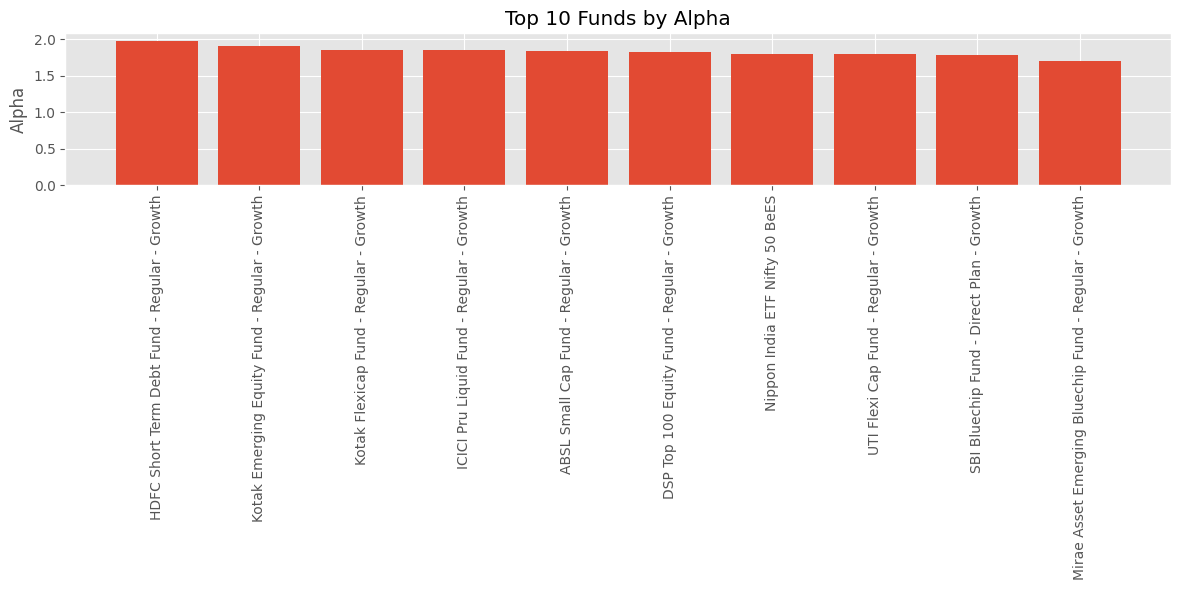

In [113]:
plt.figure(figsize=(12,6))

top10 = top_alpha.head(10)

plt.bar(
    top10["scheme_name"],
    top10["alpha"]
)

plt.xticks(rotation=90)

plt.ylabel("Alpha")

plt.title("Top 10 Funds by Alpha")

plt.tight_layout()

plt.show()

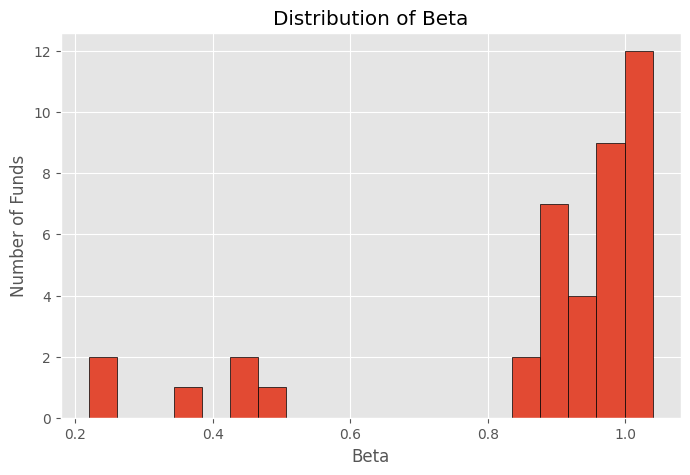

In [114]:
plt.figure(figsize=(8,5))

plt.hist(
    performance["beta"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Beta")

plt.ylabel("Number of Funds")

plt.title("Distribution of Beta")

plt.show()

In [116]:
alpha_beta.to_csv(
    os.path.join(
        processed,
        r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\processed\alpha_beta.csv"
    ),
    index=False
)

In [117]:
max_drawdown_pct

NameError: name 'max_drawdown_pct' is not defined